# U-Net — Ewaluacja Segmentacji Binarnej 128x128

In [8]:
import torch
import os
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from scipy.ndimage import binary_dilation, binary_erosion
from predict import predict_img
from torch.utils.data import random_split
from utils.data_loading import BasicDataset

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Using device: {device}")

image_dir = 'Dataset/Breast-Ultrasound-Processed/images/'
mask_dir  = 'Dataset/Breast-Ultrasound-Processed/masks/'

# Ścieżki do poszczególnych modeli
BCE_CKPT = 'checkpoints_breast_bce/checkpoint_epoch10.pth'
DICE_CKPT = 'checkpoints_breast_dice/checkpoint_epoch10.pth'
AUG_CKPT  = 'checkpoints_breast_aug/checkpoint_epoch10.pth'

target_size = (128, 128)

def load_model(checkpoint_path):
    if not os.path.exists(checkpoint_path):
        print(f"Brak pliku {checkpoint_path} - pomijam ładowanie.")
        return None
    net = smp.Unet('resnet34', encoder_weights=None, in_channels=3, classes=1)
    net.to(device=device)
    state = torch.load(checkpoint_path, map_location=device)
    state.pop('mask_values', None)
    net.load_state_dict(state)
    net.n_classes = 1
    return net

def calculate_metrics(pred_mask, true_mask):
    pred = (pred_mask > 0).astype(int)
    true = (true_mask > 0).astype(int)
    
    tp = np.sum((pred == 1) & (true == 1))
    tn = np.sum((pred == 0) & (true == 0))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))

    # Analiza krawędziowa
    dil = binary_dilation(true == 1)
    ero = binary_erosion(true == 1)
    edge_mask = dil ^ ero

    edge_pixels = edge_mask.sum()
    edge_accuracy = 0
    if edge_pixels > 0:
        pred_on_edge = pred[edge_mask]
        true_on_edge = true[edge_mask]
        edge_TP = int((pred_on_edge & true_on_edge).sum())
        edge_accuracy = edge_TP / edge_pixels
    
    return {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn, 'edge_pixels': edge_pixels, 'edge_accuracy': edge_accuracy}

def get_validation_files(img_dir, msk_dir):
    dataset = BasicDataset(img_dir, msk_dir)
    n_val = int(len(dataset) * 0.1)
    n_train = len(dataset) - n_val
    _, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(0))
    return [os.path.join(img_dir, dataset.ids[i] + '.png') for i in val_set.indices]

def evaluate_on_dataset(net, img_dir, msk_dir):
    if net is None:
        return
    files = get_validation_files(img_dir, msk_dir)
    print(f"Evaluating on {len(files)} validation images...")
    cum = {'TP': 0, 'FP': 0, 'FN': 0, 'TN': 0, 'edge_pixels': 0, 'edge_accuracy': 0}
    
    for img_path in files:
        name = os.path.splitext(os.path.basename(img_path))[0]
        msk_path = os.path.join(msk_dir, name + '.png')
        if not os.path.exists(msk_path):
            continue
            
        img = Image.open(img_path).convert('RGB').resize(target_size, Image.Resampling.BILINEAR)
        true_mask = np.asarray(Image.open(msk_path).resize(target_size, Image.Resampling.NEAREST))
        
        pred_mask = predict_img(net, img, device, target_size=128)
        
        m = calculate_metrics(pred_mask, true_mask)
        for k in cum: cum[k] += m[k]

    n = len(files)
    correct   = cum['TP'] + cum['TN']
    total     = max(correct + cum['FP'] + cum['FN'], 1)
    precision = cum['TP'] / max(cum['TP'] + cum['FP'], 1)
    recall    = cum['TP'] / max(cum['TP'] + cum['FN'], 1)
    iou       = cum['TP'] / max(cum['TP'] + cum['FP'] + cum['FN'], 1)

    print(f"  Total pixels:     {total:,}")
    print(f"  Correct:          {correct:,}  (TP={cum['TP']:,}  TN={cum['TN']:,})")
    print(f"  False positives:  {cum['FP']:,}")
    print(f"  False negatives:  {cum['FN']:,}")
    print(f"  Pixel accuracy:   {correct / total:.2%}")
    print(f"  Precision:        {precision:.2%}")
    print(f"  Recall:           {recall:.2%}")
    print(f"  IoU (Jaccard):    {iou:.2%}")
    print(f"  Edge pixels:      {cum['edge_pixels']:,}")
    print(f"  Edge accuracy:    {cum['edge_accuracy'] / n:.2%}")
    return {'iou': iou * 100, 'precision': precision * 100, 'recall': recall * 100}


Using device: mps


## Wczytywanie i Ewaluacja modeli

In [9]:
print("--- Model BCE ---")
net_bce = load_model(BCE_CKPT)
evaluate_on_dataset(net_bce, image_dir, mask_dir)

print("--- Model Dice ---")
net_dice = load_model(DICE_CKPT)
evaluate_on_dataset(net_dice, image_dir, mask_dir)

print("--- Model z Augmentacją ---")
net_aug = load_model(AUG_CKPT)
evaluate_on_dataset(net_aug, image_dir, mask_dir)


--- Model BCE ---


100%|██████████| 780/780 [00:01<00:00, 463.55it/s]


Evaluating on 78 validation images...
  Total pixels:     1,277,952
  Correct:          1,171,759  (TP=31,643  TN=1,140,116)
  False positives:  40,970
  False negatives:  65,223
  Pixel accuracy:   91.69%
  Precision:        43.58%
  Recall:           32.67%
  IoU (Jaccard):    22.96%
  Edge pixels:      16,034
  Edge accuracy:    18.05%
--- Model Dice ---


100%|██████████| 780/780 [00:01<00:00, 454.82it/s]


Evaluating on 78 validation images...
  Total pixels:     1,277,952
  Correct:          1,190,653  (TP=44,188  TN=1,146,465)
  False positives:  34,621
  False negatives:  52,678
  Pixel accuracy:   93.17%
  Precision:        56.07%
  Recall:           45.62%
  IoU (Jaccard):    33.61%
  Edge pixels:      16,034
  Edge accuracy:    18.70%
--- Model z Augmentacją ---


100%|██████████| 780/780 [00:01<00:00, 521.97it/s]


Evaluating on 78 validation images...
  Total pixels:     1,277,952
  Correct:          1,144,594  (TP=61,103  TN=1,083,491)
  False positives:  97,595
  False negatives:  35,763
  Pixel accuracy:   89.56%
  Precision:        38.50%
  Recall:           63.08%
  IoU (Jaccard):    31.42%
  Edge pixels:      16,034
  Edge accuracy:    25.38%


{'iou': 31.4217246645857,
 'precision': 38.5026906451247,
 'recall': 63.07992484463073}

## Wizualizacja predykcji na przykładowym obrazie z walidacji

100%|██████████| 780/780 [00:01<00:00, 484.18it/s]


--- Wizualizacja: Model BCE ---


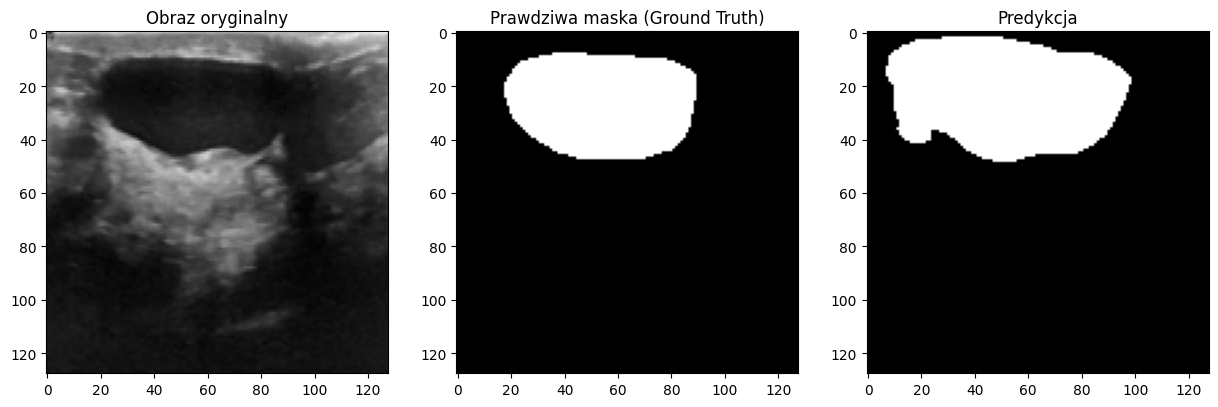

--- Wizualizacja: Model Dice ---


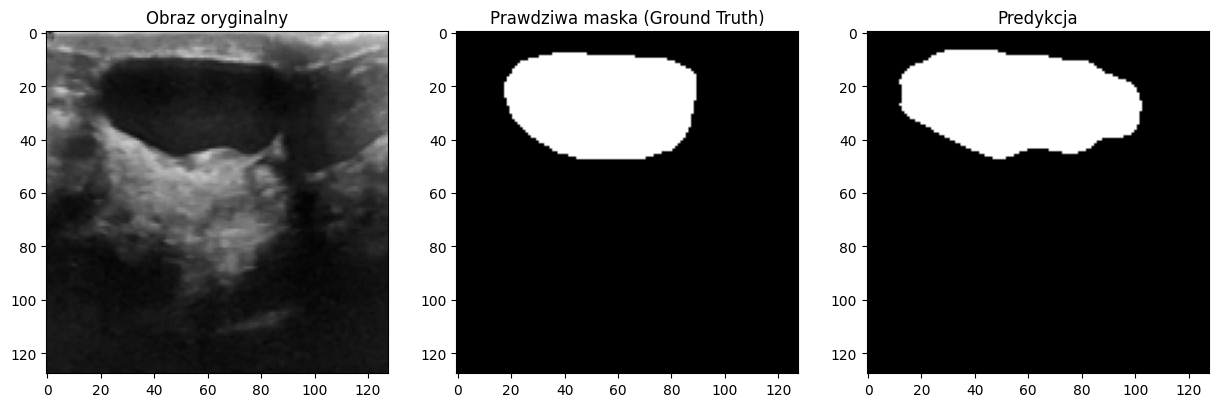

--- Wizualizacja: Model Augmentacja ---


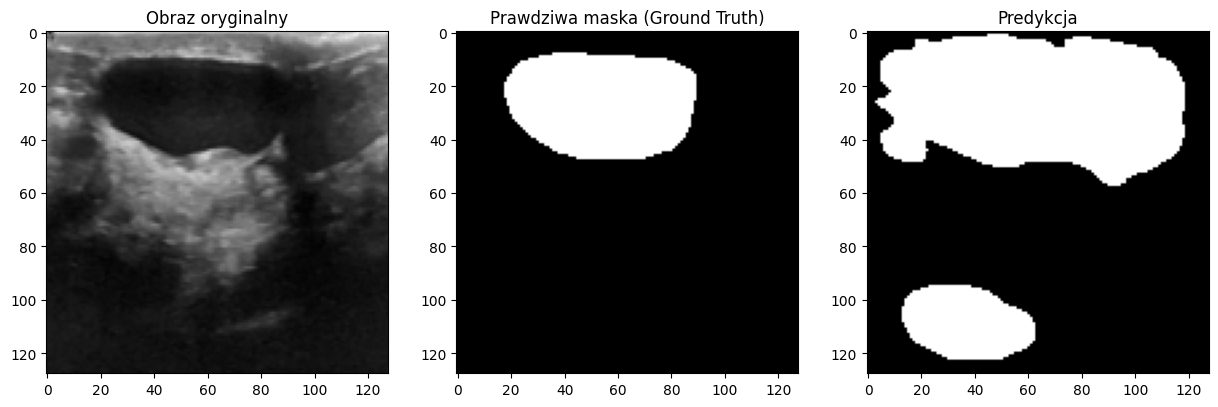

In [10]:
def visualize_prediction(net, img_path, msk_path):
    if net is None:
        return
    img = Image.open(img_path).convert('RGB').resize(target_size, Image.Resampling.BILINEAR)
    true_mask = np.asarray(Image.open(msk_path).resize(target_size, Image.Resampling.NEAREST))
    pred_mask = predict_img(net, img, device, target_size=128)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title("Obraz oryginalny")
    axes[1].imshow(true_mask > 0, cmap='gray')
    axes[1].set_title("Prawdziwa maska (Ground Truth)")
    axes[2].imshow(pred_mask > 0, cmap='gray')
    axes[2].set_title("Predykcja")
    plt.show()

val_files = get_validation_files(image_dir, mask_dir)
if len(val_files) > 0:
    sample_img = val_files[1]
    sample_msk = sample_img.replace('images', 'masks')
    
    print("--- Wizualizacja: Model BCE ---")
    visualize_prediction(net_bce, sample_img, sample_msk)
    
    print("--- Wizualizacja: Model Dice ---")
    visualize_prediction(net_dice, sample_img, sample_msk)
    
    print("--- Wizualizacja: Model Augmentacja ---")
    visualize_prediction(net_aug, sample_img, sample_msk)
